In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('AirPassengers.csv')
data.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### Preprocessing

In [4]:
data = data.rename(columns={'Month':'Date'})

data['Month'] = [int(i.split('-')[1]) for i in data['Date']]
data['Year'] = [int(i.split('-')[0]) for i in data['Date']]

data['Series'] = np.arange(1, len(data)+1)

data.drop(['Date'], axis=1, inplace=True)
data = data[['Series', 'Year', 'Month', '#Passengers']]

data.head()

,Series,Year,Month,#Passengers
0,1,1949,1,112
1,2,1949,2,118
2,3,1949,3,132
3,4,1949,4,129
4,5,1949,5,121


### Splitting

In [5]:
train = data[data['Year'] < 1960]
test = data[data['Year'] >= 1960]

train.shape, test.shape

((132, 4), (12, 4))

In [12]:
from pycaret.regression import *

s = setup(data = train, 
          test_data = test, 
          target = '#Passengers', 
          fold_strategy= 'timeseries', 
          numeric_features= ['Year', 'Series'], 
          fold=3, 
          transform_target=True, 
          session_id=123,
          data_split_shuffle = False,
          fold_shuffle = False)

,Description,Value
0,Session id,123
1,Target,#Passengers
2,Target type,Regression
3,Original data shape,"(144, 4)"
4,Transformed data shape,"(144, 4)"
5,Transformed train set shape,"(132, 4)"
6,Transformed test set shape,"(12, 4)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,simple


In [13]:
best = compare_models(sort = 'MAE')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
omp,Orthogonal Matching Pursuit,44.3192,3050.6952,53.8852,-0.4522,0.1714,0.1521,0.0433
br,Bayesian Ridge,45.5643,3233.7133,55.6766,-0.6553,0.1765,0.1576,0.0700
lr,Linear Regression,45.7431,3261.7577,55.8899,-0.6723,0.1771,0.1583,3.1033
ridge,Ridge Regression,45.7835,3257.2206,55.8542,-0.6687,0.1770,0.1585,0.0433
lar,Least Angle Regression,45.8053,3260.6009,55.8841,-0.6721,0.1771,0.1586,0.0467
huber,Huber Regressor,46.0420,3308.9723,56.4600,-0.8186,0.1802,0.1618,0.0533
lasso,Lasso Regression,51.7106,3939.2790,61.4955,-1.4896,0.2374,0.1830,1.4700
llar,Lasso Least Angle Regression,51.7106,3939.2790,61.4955,-1.4896,0.2374,0.1830,0.0467
gbr,Gradient Boosting Regressor,52.4896,4355.4048,63.7434,-0.7220,0.2142,0.1618,0.1033
en,Elastic Net,52.5924,3937.1760,61.2301,-1.4778,0.2367,0.1870,0.0467


In [18]:
future_dates = pd.date_range(start = '1961-01-01', end = '1965-01-01', freq = 'MS')
future_df = pd.DataFrame()
future_df['Month'] = [i.month for i in future_dates]
future_df['Year'] = [i.year for i in future_dates]
future_df['Series'] = np.arange(145, (145+len(future_dates)))
future_df.head()

,Month,Year,Series
0,1,1961,145
1,2,1961,146
2,3,1961,147
3,4,1961,148
4,5,1961,149


In [20]:
predictions_future = predict_model(best, data=future_df)
predictions_future.head()

,Month,Year,Series,prediction_label
0,1,1961,145,524.718637
1,2,1961,146,529.610707
2,3,1961,147,534.542524
3,4,1961,148,539.514364
4,5,1961,149,544.526504


<Axes: >

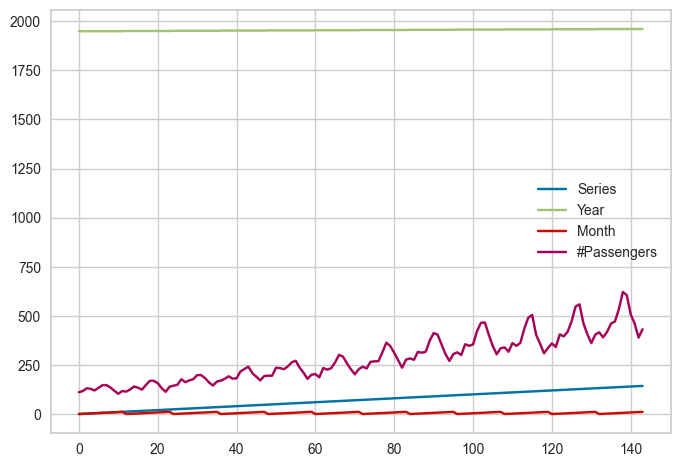

In [23]:
data.plot()

<Axes: >

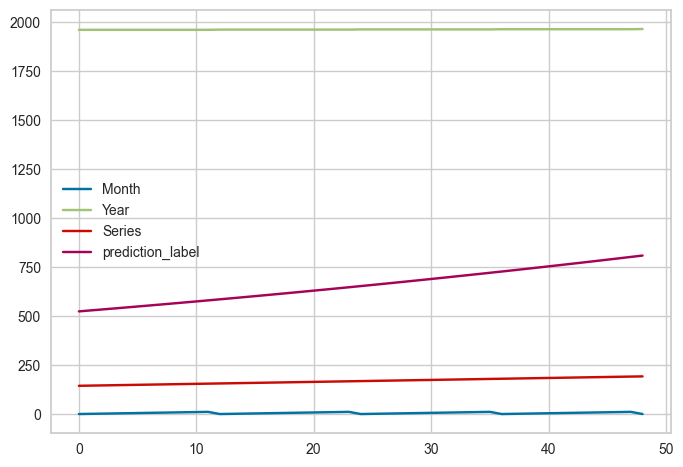

In [24]:
predictions_future.plot()